# ModC Week 6 — Decision Trees and Random Forests

**Domain:** Marketing Conversion Propensity  
**Datasets:** Predict Conversion in Digital Marketing; Google Ads Sales

Decision trees and random forests for binary conversion classification and continuous conversion-volume prediction, with overfitting control, hyperparameter tuning, and feature-importance analysis.

## 1. Imports and Data Loading

In [25]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

def find_data_root() -> Path:
    marker = 'marketing_and_product_performance.csv'
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / 'data'
        if (data_dir / marker).exists():
            return data_dir
    return Path('data')

DATA_ROOT = find_data_root()

DATASET_PATHS = {
    'Marketing and Product Performance': DATA_ROOT / 'marketing_and_product_performance.csv',
    'Predict Conversion in Digital Marketing': DATA_ROOT / 'digital_marketing_campaign_dataset.csv',
    'Google Ads Sales': DATA_ROOT / 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv',
}

def load_dataset(name: str) -> pd.DataFrame:
    path = DATASET_PATHS[name]
    if not path.exists():
        raise FileNotFoundError(
            f"Missing file for '{name}': {path.resolve()}\n"
            f"Current working directory: {Path.cwd()}\n"
            f"Run: python download_datasets.py"
        )
    df = pd.read_csv(path)
    print(f'{name} loaded: {path.name} | shape={df.shape}')
    return df

def pick_column(df, candidates):
    lower_map = {c.lower().replace(' ', '_'): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(' ', '_')
        if key in lower_map:
            return lower_map[key]
    for col in df.columns:
        norm = col.lower().replace(' ', '_')
        if any(cand.lower().replace(' ', '_') in norm for cand in candidates):
            return col
    return None

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2': r2_score(y_true, y_pred), 'RMSE': rmse}

def clean_currency(series):
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.replace(r'[\$,]', '', regex=True),
            errors='coerce',
        )
    return series

def prepare_google_ads_sales(df):
    prepared = df.copy()
    for col in ['Cost', 'Sale_Amount']:
        if col in prepared.columns:
            prepared[col] = clean_currency(prepared[col])

    target_col = pick_column(prepared, ['Conversions', 'Leads', 'Conversion Rate', 'Sale_Amount'])
    if target_col is None or prepared[target_col].notna().sum() < 100:
        raise ValueError('Could not find a suitable regression target in Google Ads Sales.')
    return prepared, target_col

def build_feature_matrix(df, target_col, max_cat_levels=12):
    model_df = df.dropna(subset=[target_col]).copy()
    id_cols = [c for c in model_df.columns if c.lower().endswith('_id') or c.lower() == 'ad_id']
    model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')

    cat_cols = model_df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        if col != target_col and model_df[col].nunique() <= max_cat_levels:
            model_df = pd.concat([
                model_df.drop(columns=[col]),
                pd.get_dummies(model_df[col], prefix=col, drop_first=True),
            ], axis=1)

    X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X = X.fillna(X.median(numeric_only=True))
    y = model_df[target_col]
    return X, y

predict_conversion = load_dataset('Predict Conversion in Digital Marketing')
google_ads_sales = load_dataset('Google Ads Sales')

Predict Conversion in Digital Marketing loaded: digital_marketing_campaign_dataset.csv | shape=(8000, 20)
Google Ads Sales loaded: GoogleAds_DataAnalytics_Sales_Uncleaned.csv | shape=(2600, 13)


## 2. EDA — Predict Conversion in Digital Marketing

Class distribution:
Conversion
1    0.8765
0    0.1235
Name: proportion, dtype: float64

Note: Imbalanced classes — accuracy alone can be misleading; use F1 and ROC-AUC.


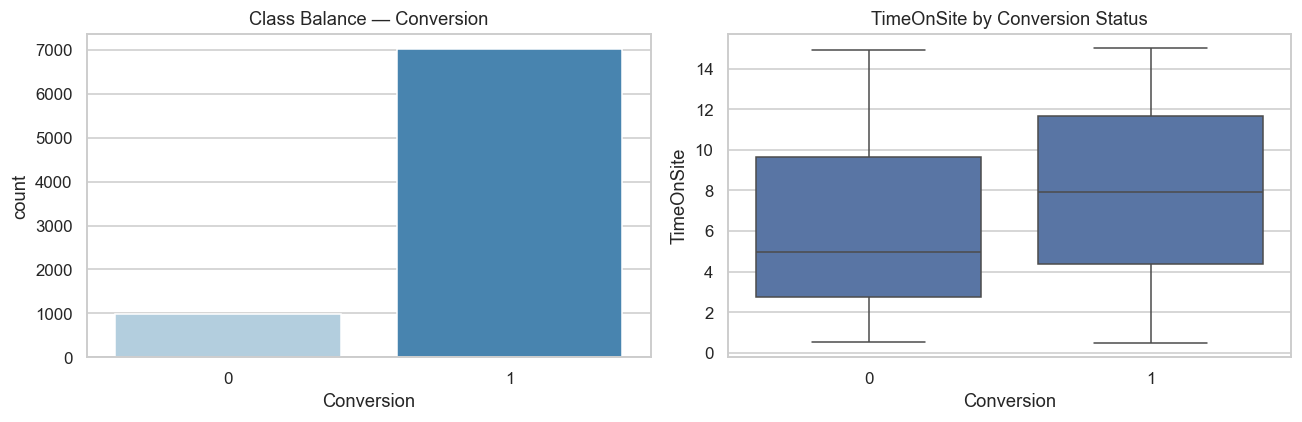

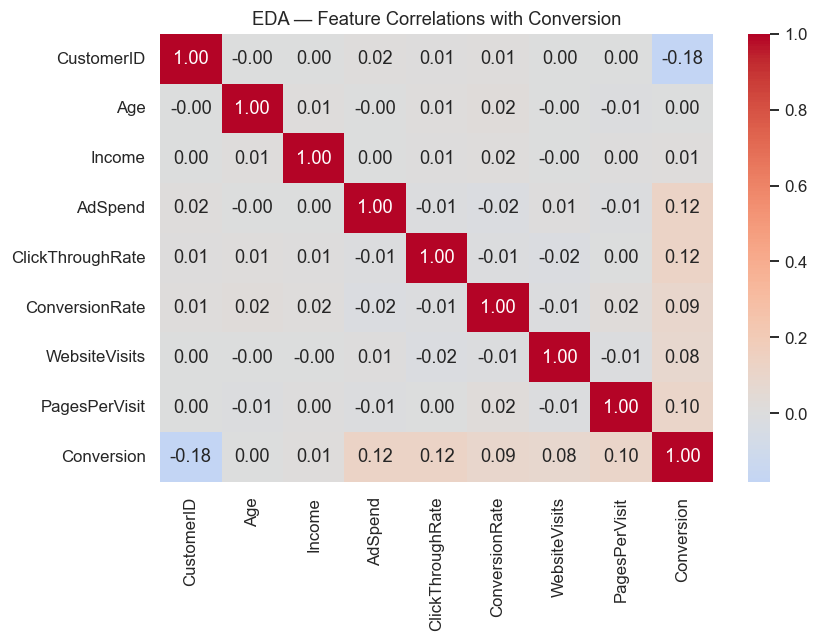

In [26]:

df = predict_conversion.copy()
target_col = pick_column(df, ['Conversion', 'Converted', 'conversion'])
if target_col is None:
    raise ValueError('Could not find binary conversion target in Predict Conversion in Digital Marketing.')

if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype(str).str.lower().map({'yes': 1, 'no': 0, 'true': 1, 'false': 0})
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

class_pct = df[target_col].value_counts(normalize=True)
print('Class distribution:')
print(class_pct)
print('\nNote: Imbalanced classes — accuracy alone can be misleading; use F1 and ROC-AUC.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x=target_col, ax=axes[0], palette='Blues')
axes[0].set_title('Class Balance — Conversion')

num_for_plot = pick_column(df, ['TimeOnSite', 'Time Spent', 'PagesPerVisit', 'AdSpend'])
if num_for_plot:
    sns.boxplot(data=df, x=target_col, y=num_for_plot, ax=axes[1])
    axes[1].set_title(f'{num_for_plot} by Conversion Status')
plt.tight_layout()
plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)
top_num = num_cols[:8]
if top_num:
    corr = df[top_num + [target_col]].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('EDA — Feature Correlations with Conversion')
    plt.tight_layout()
    plt.show()


## 3. Classification Preprocessing

In [27]:

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
model_df = df.dropna(subset=[target_col]).copy()

for col in cat_cols:
    if col != target_col and model_df[col].nunique() <= 15:
        model_df = pd.concat([
            model_df.drop(columns=[col]),
            pd.get_dummies(model_df[col], prefix=col, drop_first=True),
        ], axis=1)

id_cols = [c for c in model_df.columns if c.lower().endswith('id')]
model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')

X_clf = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number])
X_clf = X_clf.fillna(X_clf.median(numeric_only=True))
y_clf = model_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)
print(f'Classification features: {X_clf.shape[1]} | Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')


Classification features: 13 | Train: 6000 | Test: 2000


## 4. Decision Tree Classifier — Overfitting

Unrestricted decision tree (test):
  ROC-AUC: 0.632
  F1: 0.903
  Tree depth: 25


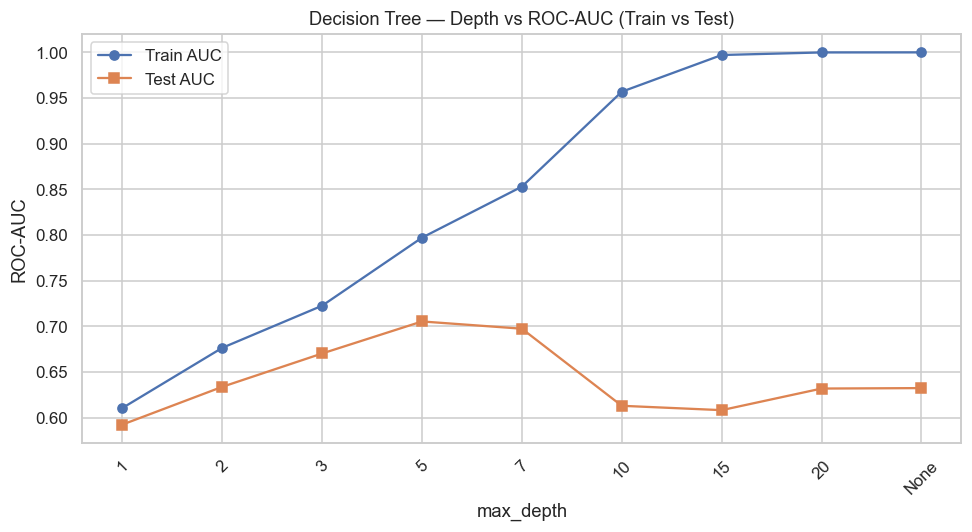

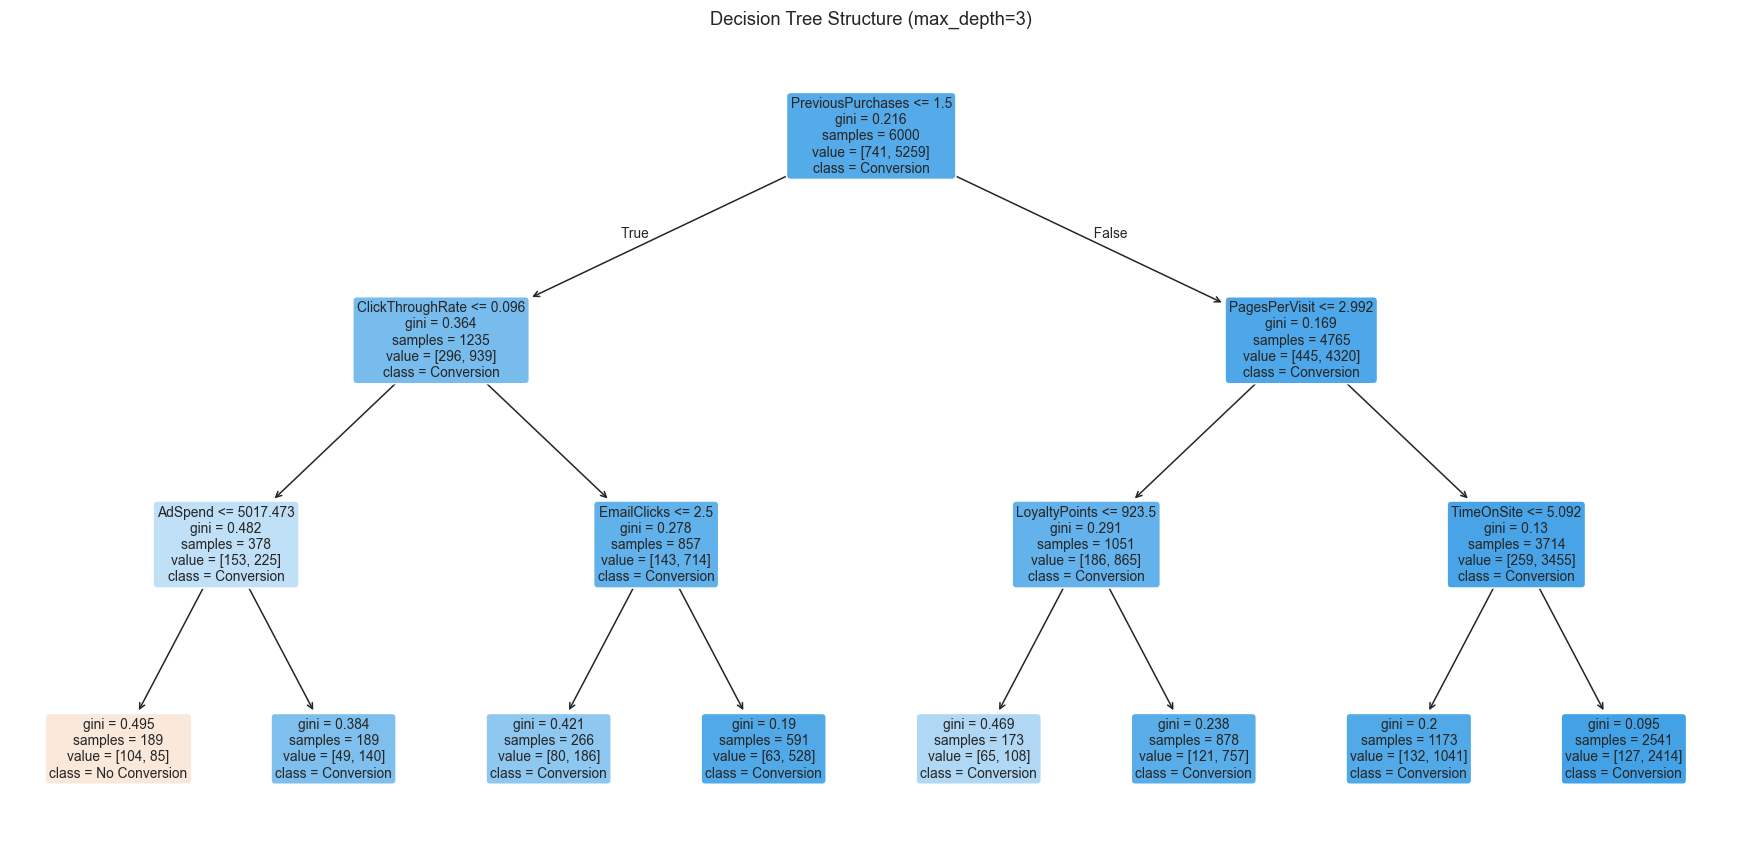

In [28]:

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)
dt_default_prob = dt_default.predict_proba(X_test)[:, 1]
dt_default_pred = dt_default.predict(X_test)

print('Unrestricted decision tree (test):')
print('  ROC-AUC:', round(roc_auc_score(y_test, dt_default_prob), 3))
print('  F1:', round(f1_score(y_test, dt_default_pred), 3))
print('  Tree depth:', dt_default.get_depth())

depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
train_aucs, test_aucs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, m.predict_proba(X_train)[:, 1]))
    test_aucs.append(roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]))

from pathlib import Path
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

depth_labels = [str(d) if d is not None else 'None' for d in depths]
plt.figure(figsize=(9, 5))
plt.plot(depth_labels, train_aucs, marker='o', label='Train AUC')
plt.plot(depth_labels, test_aucs, marker='s', label='Test AUC')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Decision Tree — Depth vs ROC-AUC (Train vs Test)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'figure6.png', bbox_inches='tight', dpi=160)
plt.show()

dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)
plt.figure(figsize=(16, 8))
plot_tree(
    dt_shallow,
    feature_names=X_clf.columns.tolist(),
    class_names=['No Conversion', 'Conversion'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
)
plt.title('Decision Tree Structure (max_depth=3)')
plt.tight_layout()
plt.show()


## 5. Hyperparameter Tuning — Decision Tree & Random Forest (Classification)

In [29]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [5, 10, 20, 30],
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
dt_grid.fit(X_train, y_train)
print('Best decision tree params:', dt_grid.best_params_)
print('Best CV ROC-AUC:', round(dt_grid.best_score_, 3))

dt_best = dt_grid.best_estimator_
dt_best_prob = dt_best.predict_proba(X_test)[:, 1]
dt_best_pred = dt_best.predict(X_test)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [5, 10],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print('Best random forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC:', round(rf_grid.best_score_, 3))

rf_best = rf_grid.best_estimator_
rf_best_prob = rf_best.predict_proba(X_test)[:, 1]
rf_best_pred = rf_best.predict(X_test)


Best decision tree params: {'max_depth': 7, 'min_samples_leaf': 20}
Best CV ROC-AUC: 0.733
Best random forest params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV ROC-AUC: 0.82


## 6. Classification Results & Feature Importance

                     Model  Accuracy     F1  ROC-AUC
0  Decision Tree (default)     0.831  0.903    0.632
1    Decision Tree (tuned)     0.876  0.932    0.704
2    Random Forest (tuned)     0.886  0.939    0.798


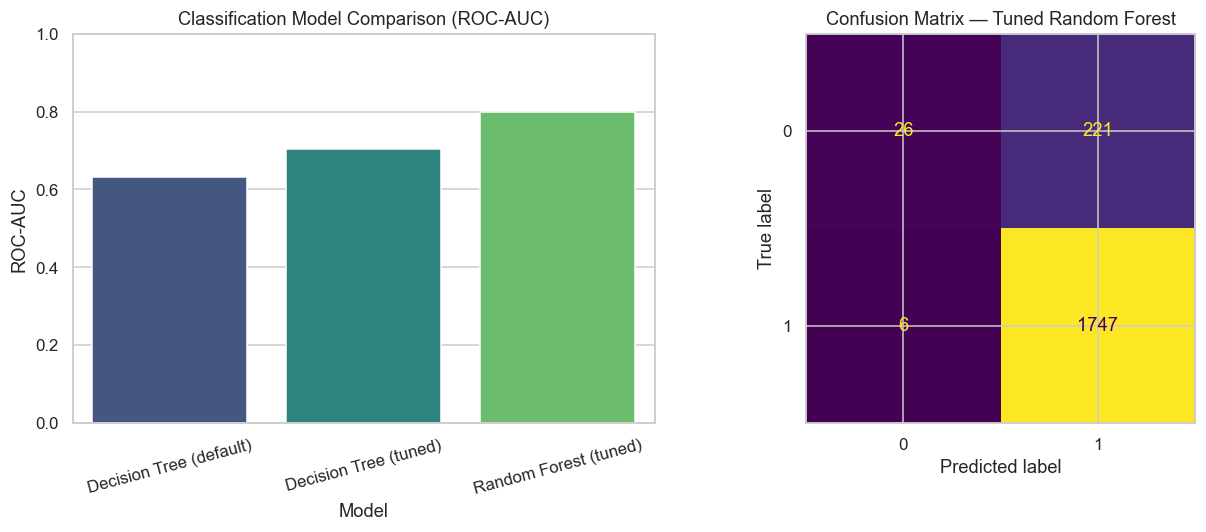

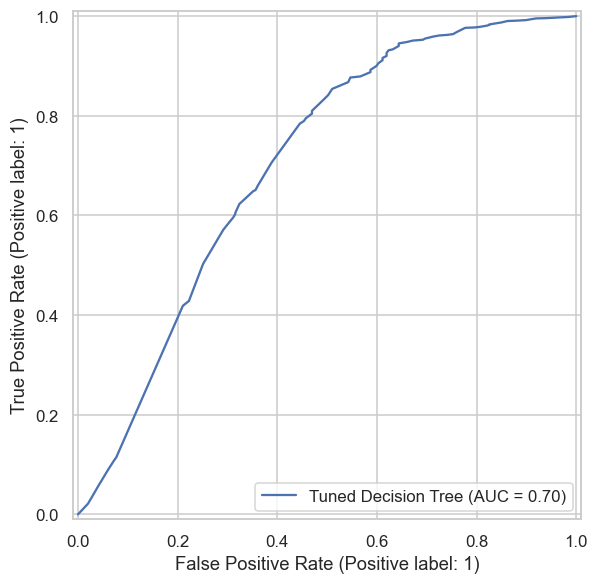

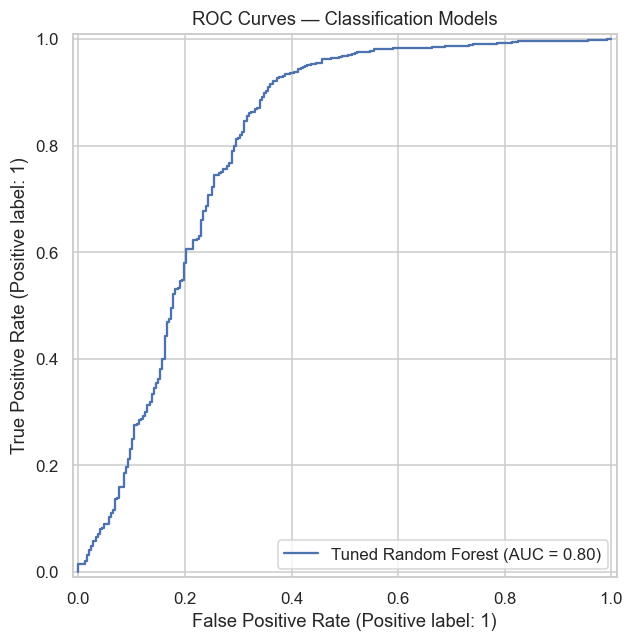

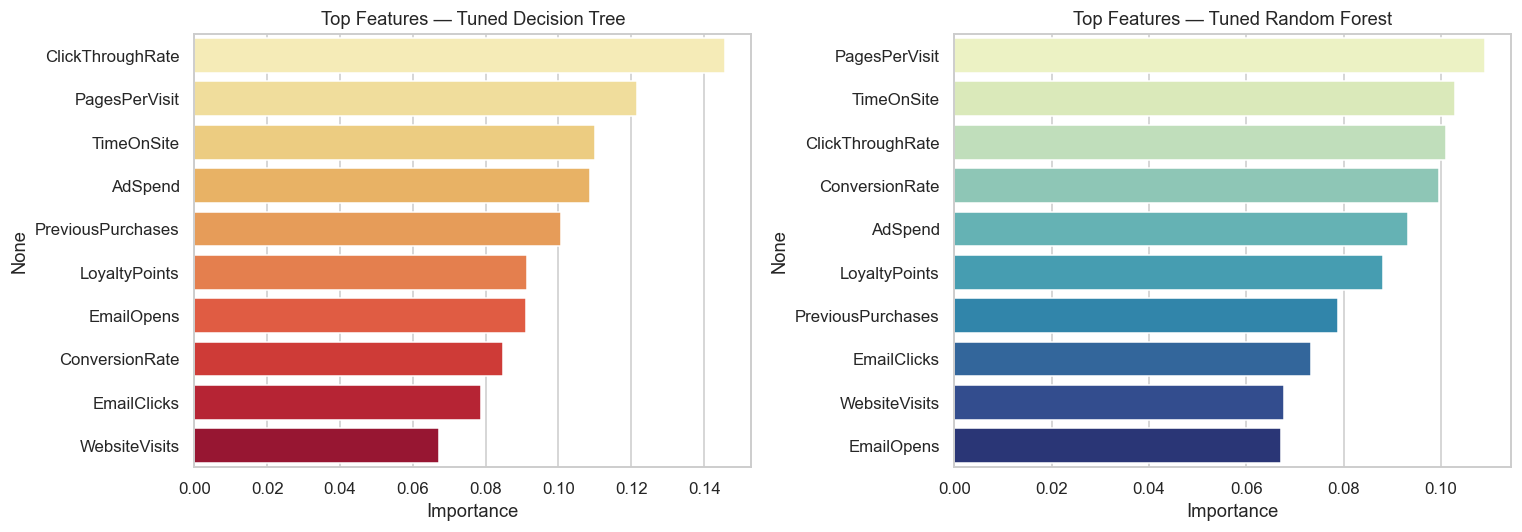

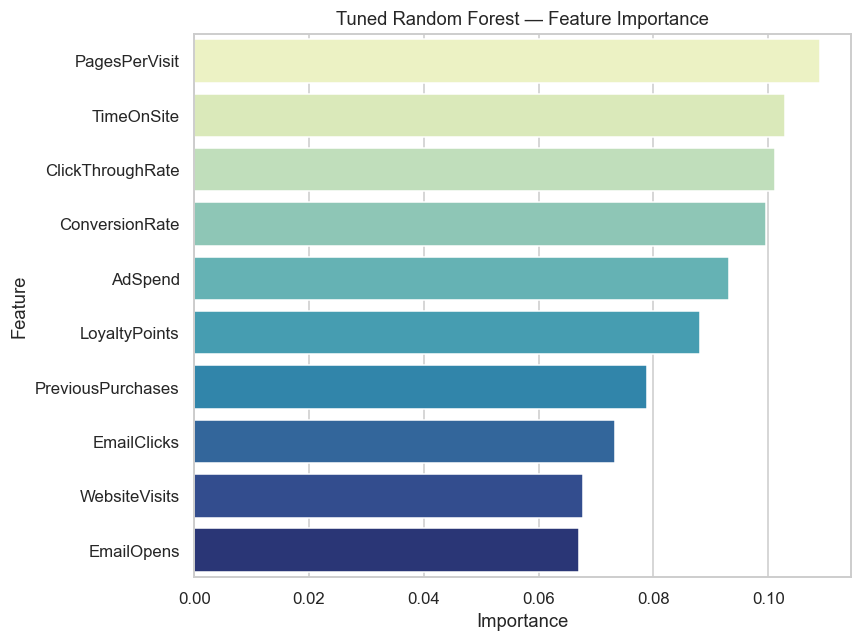

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

def clf_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
    }

clf_results = pd.DataFrame([
    {'Model': 'Decision Tree (default)', **clf_metrics(y_test, dt_default_pred, dt_default_prob)},
    {'Model': 'Decision Tree (tuned)', **clf_metrics(y_test, dt_best_pred, dt_best_prob)},
    {'Model': 'Random Forest (tuned)', **clf_metrics(y_test, rf_best_pred, rf_best_prob)},
])
print(clf_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=clf_results, x='Model', y='ROC-AUC', palette='viridis', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Classification Model Comparison (ROC-AUC)')
axes[0].tick_params(axis='x', rotation=15)

ConfusionMatrixDisplay.from_predictions(y_test, rf_best_pred, ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, dt_best_prob, name='Tuned Decision Tree')
RocCurveDisplay.from_predictions(y_test, rf_best_prob, name='Tuned Random Forest')
plt.title('ROC Curves — Classification Models')
plt.tight_layout()
plt.show()

dt_imp = pd.Series(dt_best.feature_importances_, index=X_clf.columns).sort_values(ascending=False).head(10)
rf_imp = pd.Series(rf_best.feature_importances_, index=X_clf.columns).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=dt_imp.values, y=dt_imp.index, palette='YlOrRd', ax=axes[0])
axes[0].set_title('Top Features — Tuned Decision Tree')
axes[0].set_xlabel('Importance')
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette='YlGnBu', ax=axes[1])
axes[1].set_title('Top Features — Tuned Random Forest')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette='YlGnBu')
plt.title('Tuned Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
plt.close()


## 7. Regression — Google Ads Sales

Dataset: Google Ads Sales | Target: Conversions
Regression features: 4 | Samples: 2526


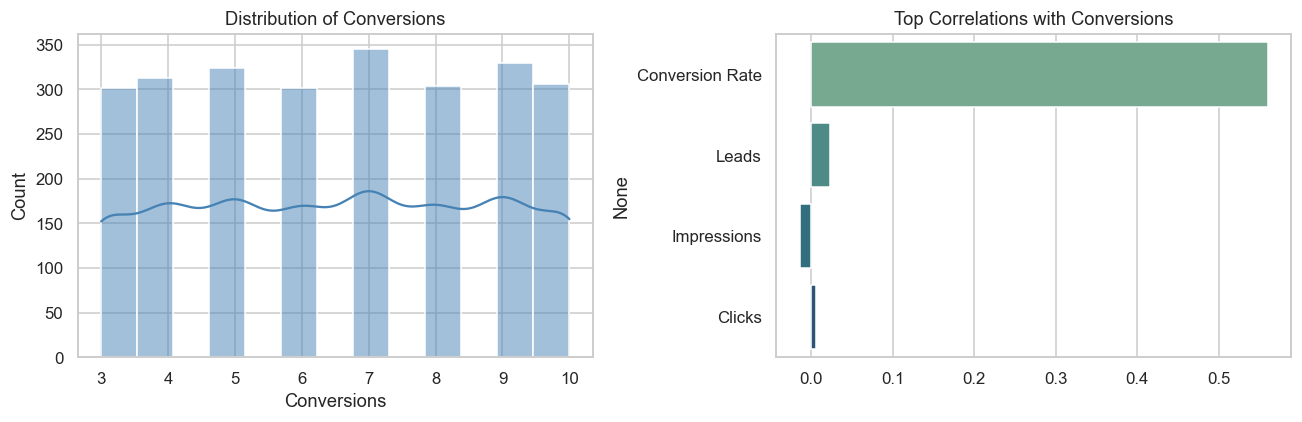

In [31]:

df_reg, target_reg = prepare_google_ads_sales(google_ads_sales)
print(f'Dataset: Google Ads Sales | Target: {target_reg}')

X_reg, y_reg = build_feature_matrix(df_reg, target_reg)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)
print(f'Regression features: {X_reg.shape[1]} | Samples: {X_reg.shape[0]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_reg, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribution of {target_reg}')
corr_reg = X_reg.corrwith(y_reg).sort_values(key=abs, ascending=False).head(8)
sns.barplot(x=corr_reg.values, y=corr_reg.index, palette='crest', ax=axes[1])
axes[1].set_title(f'Top Correlations with {target_reg}')
plt.tight_layout()
plt.show()


## 8. Decision Tree & Random Forest Regressors

Best decision tree regressor params: {'max_depth': 7, 'min_samples_leaf': 10}
Best random forest regressor params: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}
                     Model     R2   RMSE
0  Decision Tree (default) -0.066  2.361
1    Decision Tree (tuned)  0.399  1.772
2    Random Forest (tuned)  0.412  1.753


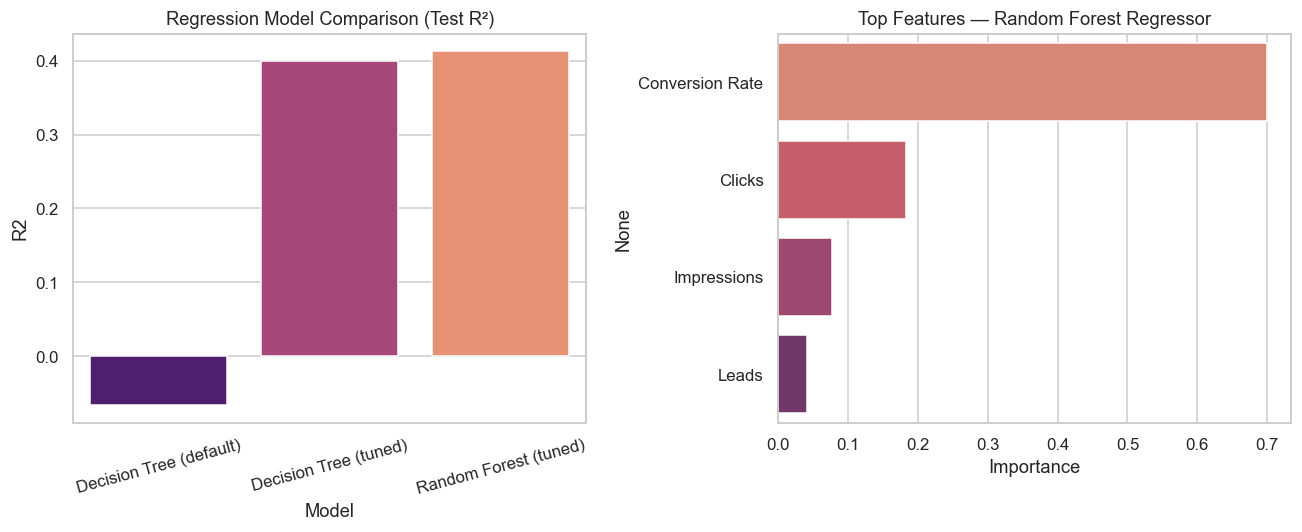

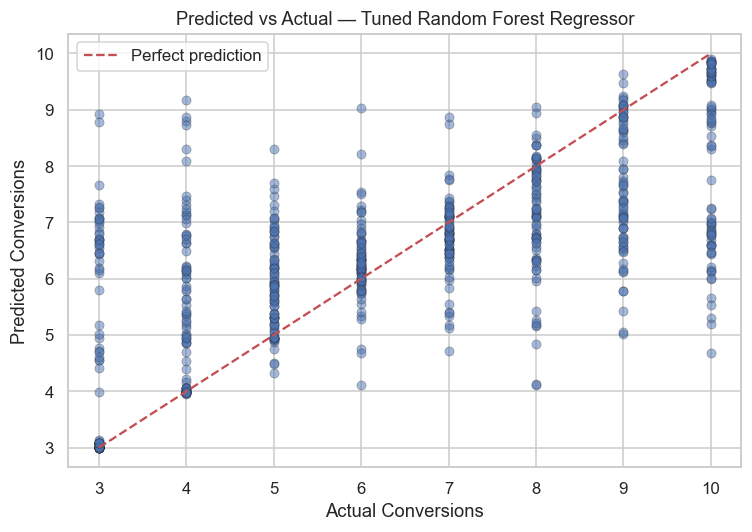

In [32]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dtr_default = DecisionTreeRegressor(random_state=42)
dtr_default.fit(Xr_train, yr_train)
metrics_dtr_default = regression_metrics(yr_test, dtr_default.predict(Xr_test))

dtr_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': [3, 5, 7, 10], 'min_samples_leaf': [5, 10, 20]},
    cv=5,
    scoring='r2',
    n_jobs=-1,
)
dtr_grid.fit(Xr_train, yr_train)
print('Best decision tree regressor params:', dtr_grid.best_params_)
dtr_best = dtr_grid.best_estimator_
metrics_dtr_tuned = regression_metrics(yr_test, dtr_best.predict(Xr_test))

rfr_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [None, 10, 15], 'min_samples_leaf': [5, 10]},
    cv=5,
    scoring='r2',
    n_jobs=-1,
)
rfr_grid.fit(Xr_train, yr_train)
print('Best random forest regressor params:', rfr_grid.best_params_)
rfr_best = rfr_grid.best_estimator_
metrics_rfr_tuned = regression_metrics(yr_test, rfr_best.predict(Xr_test))

reg_results = pd.DataFrame([
    {'Model': 'Decision Tree (default)', **metrics_dtr_default},
    {'Model': 'Decision Tree (tuned)', **metrics_dtr_tuned},
    {'Model': 'Random Forest (tuned)', **metrics_rfr_tuned},
])
print(reg_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=reg_results, x='Model', y='R2', palette='magma', ax=axes[0])
axes[0].set_title('Regression Model Comparison (Test R²)')
axes[0].tick_params(axis='x', rotation=15)

rfr_imp = pd.Series(rfr_best.feature_importances_, index=X_reg.columns).sort_values(ascending=False).head(10)
sns.barplot(x=rfr_imp.values, y=rfr_imp.index, palette='flare', ax=axes[1])
axes[1].set_title('Top Features — Random Forest Regressor')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.show()

yr_pred = rfr_best.predict(Xr_test)
plt.figure(figsize=(7, 5))
plt.scatter(yr_test, yr_pred, alpha=0.5, edgecolor='k', linewidth=0.3)
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel(f'Actual {target_reg}')
plt.ylabel(f'Predicted {target_reg}')
plt.title('Predicted vs Actual — Tuned Random Forest Regressor')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Conclusions

**EDA & preprocessing:** Predict Conversion in Digital Marketing is imbalanced (~88% converted), so F1 and ROC-AUC are more informative than accuracy alone. EDA correlations guided which engagement features (TimeOnSite, PagesPerVisit, ClickThroughRate) to expect in tree splits. ID columns were removed to avoid spurious leakage.

**Overfitting (classification):** An unrestricted decision tree achieved high training AUC but weaker test generalization. Limiting `max_depth` and increasing `min_samples_leaf` through cross-validated grid search is the right mitigation because it prevents the tree from creating very specific leaves that memorize the training data.

**Tree and random forest classification:** The random forest is the strongest Week 6 classification model because it averages many decorrelated trees and reduces variance compared with a single tree. This supports using tree ensembles as the main depth model for conversion propensity.

**Regression caution:** The Google Ads tree-regression section uses the same helper pipeline as Weeks 1-2, which retains `Conversion Rate` as a predictor for `Conversions`. Therefore, any strong RF regression result should be treated as descriptive rather than a clean prediction result. In the corrected Milestone 1 notebook, `Conversion Rate` and `Sale_Amount` are removed before regression, and the remaining Google Ads fields show weak out-of-sample signal.

**Hyperparameters:** `max_depth` caps tree complexity; `min_samples_leaf` prevents splits on tiny leaf nodes; `n_estimators` averages many trees to reduce random forest variance. CV-selected settings balance bias and variance for each task.

**Metrics:** Classification uses Accuracy, F1, and ROC-AUC, with emphasis on F1/ROC-AUC because of class imbalance. Regression uses R² and RMSE, but regression conclusions must be based on leakage-free predictors.

**Expected vs unexpected:** Engagement metrics ranking high in RF feature importance was expected. Unexpected: the Google Ads regression story changes substantially after leakage removal, so classification on the digital marketing dataset is the more reliable predictive path for Milestone One.

**Milestone link:** Week 6 completes the required breadth with decision trees and random forests, while the corrected Milestone 1 notebook provides the cleaner final interpretation.